## Capstone Project: Predicting Emergency Hospital Admissions Using Machine Learning
### A Predictive Model for Identifying Patients Likely to Require Emergency Admission

Rationale - This problem is important because emergency department overcrowding is a growing challenge in healthcare systems, including Atlantic Canada, leading to long wait times and resource constraints.

https://en.wikipedia.org/wiki/Healthcare_in_Canada?utm_source=chatgpt.com

https://globalnews.ca/news/11569773/new-brunswick-er-wait-times/?utm_source=chatgpt.com


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MultipleLocator

import warnings
warnings.filterwarnings('ignore')

### Load the dataset

In [3]:
data = pd.read_csv("Healthcare_data.csv")

In [4]:
# Dimensionality of the data - Exploring the number of rows and columns 
data.shape

(55500, 15)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

***Comment*** - No missing data in the dataset

In [6]:
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


### Descriptive Statistics

In [7]:
# Numerical Statistical Analysis
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,55500.0,51.539459,19.602454,13.00000,35.000000,52.000000,68.000000,89.000000
Billing Amount,55500.0,25539.316097,14211.454431,-2008.49214,13241.224652,25538.069376,37820.508436,52764.276736
Room Number,55500.0,301.134829,115.243069,101.00000,202.000000,302.000000,401.000000,500.000000


**Comments*** Mean and median values of numerical variables indicate a normal distribution

In [8]:
# Categorical Statistical Analysis
data.describe(include="object").T

,count,unique,top,freq
Name,55500,49992,DAvId muNoZ,3
Gender,55500,2,Male,27774
Blood Type,55500,8,A-,6969
Medical Condition,55500,6,Arthritis,9308
Date of Admission,55500,1827,2024-03-16,50
Doctor,55500,40341,Michael Smith,27
Hospital,55500,39876,LLC Smith,44
Insurance Provider,55500,5,Cigna,11249
Admission Type,55500,3,Elective,18655
Discharge Date,55500,1856,2020-03-15,53


In [9]:
# Inspecting unique levels in categorical variables in Trips table
cat_cols = ['Blood Type','Medical Condition','Insurance Provider','Admission Type', 'Test Results', 'Medication']

for column in cat_cols:
    print(f"\nUnique values in {column}:")
    print(data[column].unique())


Unique values in Blood Type:
['B-' 'A+' 'A-' 'O+' 'AB+' 'AB-' 'B+' 'O-']

Unique values in Medical Condition:
['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']

Unique values in Insurance Provider:
['Blue Cross' 'Medicare' 'Aetna' 'UnitedHealthcare' 'Cigna']

Unique values in Admission Type:
['Urgent' 'Emergency' 'Elective']

Unique values in Test Results:
['Normal' 'Inconclusive' 'Abnormal']

Unique values in Medication:
['Paracetamol' 'Ibuprofen' 'Aspirin' 'Penicillin' 'Lipitor']


In [10]:
data["Admission Type"].value_counts()

Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

In [20]:
data["EmergencyFlag"] = (
    data["Admission Type"] == "Emergency"
).astype(int)

data["EmergencyFlag"].value_counts()

EmergencyFlag
0    36864
1    18102
Name: count, dtype: int64

***Comment*** Create Target class (Emergency_Flag) from  'Type of Admission' variable. Emergency = 1, Elective/Urgent = 0. Elective/Urgent will be represented as 'Non Emergency'

In [12]:
# Count the number of unique values in the 'Name' column of the dataframe
unique_count = data['Name'].nunique()
# Print the count of unique names
print(unique_count)

49992


**Comments** about 5508 names are not unique

In [14]:
# Count the number of duplicate rows in the dataset
duplicate_count = data.duplicated().sum()
# Print the total number of duplicate rows found
print(duplicate_count)

534


**Comments** There are 534 duplicated rows in the dataset

In [16]:
# Remove duplicate rows from the dataframe to ensure data integrity
data = data.drop_duplicates()

In [17]:
data.shape

(54966, 15)

**Comments** Duplicate rows have neen removed

In [18]:
# Categorical Statistical Analysis
data.describe(include="object").T

,count,unique,top,freq
Name,54966,49992,DAvId muNoZ,3
Gender,54966,2,Male,27496
Blood Type,54966,8,A-,6898
Medical Condition,54966,6,Arthritis,9218
Date of Admission,54966,1827,2024-03-16,50
Doctor,54966,40341,Michael Smith,27
Hospital,54966,39876,LLC Smith,44
Insurance Provider,54966,5,Cigna,11139
Admission Type,54966,3,Elective,18473
Discharge Date,54966,1856,2020-03-15,53


### Target Variable Distribution

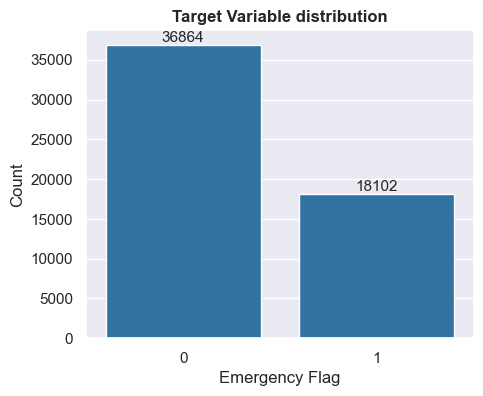

In [21]:
# Target variable visualization
sns.set(style="darkgrid", palette="tab10", font="sans-serif", font_scale=1)

plt.figure(figsize=(5,4))
ax = sns.countplot(data=data, x='EmergencyFlag')

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.title("Target Variable distribution", fontweight='bold')
plt.xlabel("Emergency Flag")
plt.ylabel("Count")
plt.show()

#plt.savefig("target_class.pdf", dpi=300, bbox_inches="tight")

### Univariate Analysis of Numeric Variables

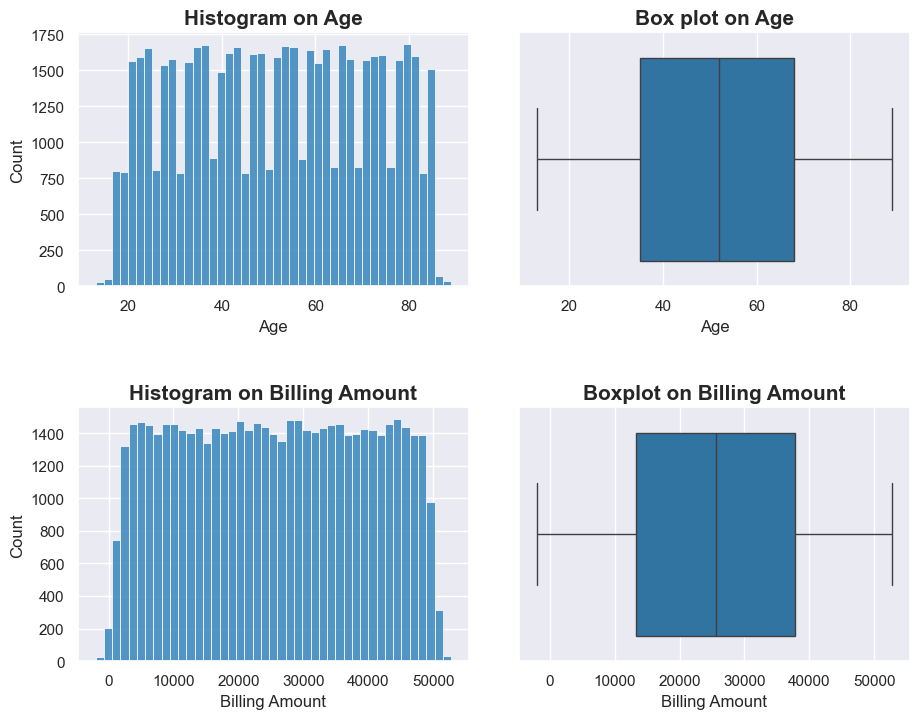

In [22]:
# Histogram and Boxplot of Numeric Variables

# Create a figure with 2x2 subplots with specified size
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10,8))

# Plot histogram of passenger count in top-left subplot
sns.histplot(x="Age", data=data, ax=axs[0,0])
axs[0,0].set_title("Histogram on Age", fontweight='bold', fontsize=15)
# axs[0,0].xaxis.set_major_locator(MultipleLocator(1))  # Force integer ticks

# Plot boxplot of passenger count in top-right subplot
sns.boxplot(x="Age", data=data, ax=axs[0,1])
axs[0,1].set_title("Box plot on Age", fontweight='bold', fontsize=15)
#axs[0,1].xaxis.set_major_locator(MultipleLocator(1))  # Force integer ticks

# Plot histogram of fare amount in bottom-left subplot
sns.histplot(x="Billing Amount", data=data, ax=axs[1,0])
axs[1,0].set_title("Histogram on Billing Amount", fontweight='bold', fontsize=15)

# Plot boxplot of fare amount in bottom-right subplot
sns.boxplot(x="Billing Amount", data=data, ax=axs[1,1])
axs[1,1].set_title("Boxplot on Billing Amount", fontweight='bold', fontsize=15)


# Adjust spacing between subplots
plt.tight_layout(pad=3.0)

#plt.savefig("num_univarate_1b.pdf", dpi=300, bbox_inches="tight")

# Display the figure with all four plots
plt.show()

**Comments**
- The distributions of Age and Billing Amount appear relatively spread across their ranges without strong skewness. No outlier in the distribution as well.
- Age values are distributed between approximately 15 and 90 years, with the median around the mid-50s, indicating that the dataset includes a wide adult population
- Billing Amount ranges from roughly $1,000 to $50,000, with the median close to $28,000–$30,000

### Univariate Analysis of Categorical Variables

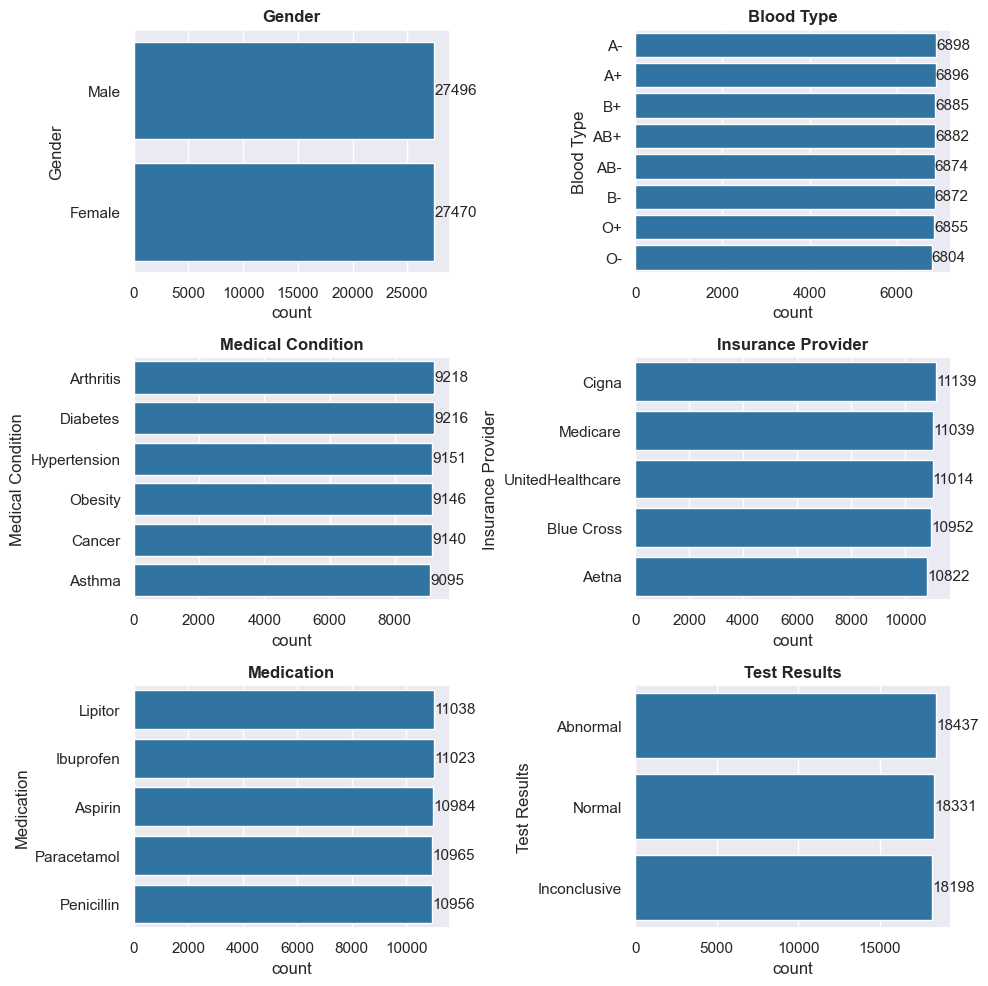

In [23]:
# Bar Plots of Categorical Variables

# Create a figure with 2x2 subplots with specified size
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10,10))

sns.countplot(y=data["Gender"], order=data["Gender"].value_counts(ascending=False).index, ax=axs[0, 0])
values = data["Gender"].value_counts(ascending=False).values # Get the count values Gender categories
axs[0, 0].bar_label(axs[0, 0].containers[0], labels=values, fontsize=11) # Add count labels on top of each bar
axs[0, 0].set_title("Gender", fontweight='bold') # Set the title for this subplot
#axs[0, 0].set_xlabel("")
#axs[0, 0].set_ylabel("")
# Increase axis tick label font size
#axs[0, 0].tick_params(axis='both', labelsize=16)


sns.countplot(y=data["Blood Type"], order=data["Blood Type"].value_counts(ascending=False).index, ax=axs[0, 1])
values = data["Blood Type"].value_counts(ascending=False).values # Get the count values for Blood Type categories
axs[0, 1].bar_label(axs[0, 1].containers[0], labels=values, fontsize=11) # Add count labels on top of each bar
axs[0, 1].set_title("Blood Type", fontweight='bold') # Set the title for this subplot
#axs[0, 1].set_xlabel("")
#axs[0, 1].set_ylabel("")
# Increase axis tick label font size
#axs[0, 1].tick_params(axis='both', labelsize=16)

sns.countplot(y=data["Medical Condition"], order=data["Medical Condition"].value_counts(ascending=False).index, ax=axs[1, 0])
values = data["Medical Condition"].value_counts(ascending=False).values # Get the count values for categories of medical condition
axs[1, 0].bar_label(axs[1, 0].containers[0], labels=values, fontsize=11) # Add count labels on top of each bar
axs[1, 0].set_title("Medical Condition", fontweight='bold') # Set the title for this subplot
#axs[1, 0].set_xlabel("")
#axs[1, 0].set_ylabel("")
# Increase axis tick label font size
#axs[1, 0].tick_params(axis='both', labelsize=16)


sns.countplot(y=data["Insurance Provider"], order=data["Insurance Provider"].value_counts(ascending=False).index, ax=axs[1, 1])
values = data["Insurance Provider"].value_counts(ascending=False).values # Get the count values for each transport mode
axs[1, 1].bar_label(axs[1, 1].containers[0], labels=values, fontsize=11) # Add count labels on top of each bar
axs[1, 1].set_title("Insurance Provider", fontweight='bold') # Set the title for this subplot
#axs[1, 1].set_xlabel("")
#axs[1, 1].set_ylabel("")
# Increase axis tick label font size
#axs[1, 1].tick_params(axis='both', labelsize=16)

sns.countplot(y=data["Medication"], order=data["Medication"].value_counts(ascending=False).index, ax=axs[2, 0])
values = data["Medication"].value_counts(ascending=False).values # Get the count values for each transport mode
axs[2, 0].bar_label(axs[2, 0].containers[0], labels=values, fontsize=11) # Add count labels on top of each bar
axs[2, 0].set_title("Medication", fontweight='bold') # Set the title for this subplot
#axs[2, 0].set_xlabel("")
#axs[2, 0].set_ylabel("")
# Increase axis tick label font size
#axs[2, 0].tick_params(axis='both', labelsize=16)

sns.countplot(y=data["Test Results"], order=data["Test Results"].value_counts(ascending=False).index, ax=axs[2, 1])
values = data["Test Results"].value_counts(ascending=False).values # Get the count values for each transport mode
axs[2, 1].bar_label(axs[2, 1].containers[0], labels=values, fontsize=11) # Add count labels on top of each bar
axs[2, 1].set_title("Test Results", fontweight='bold') # Set the title for this subplot
#axs[2, 1].set_xlabel("")
#axs[2, 1].set_ylabel("")
# Increase axis tick label font size
#axs[2, 1].tick_params(axis='both', labelsize=16)

# Adjust spacing between subplots
plt.tight_layout(pad=1.0)

#plt.savefig("num_univarate_1b.pdf", dpi=300, bbox_inches="tight")

# Display the figure with all four plots
plt.show()

**Comments** 
- The categorical variables in the dataset appear fairly balanced across categories, indicating no severe dominance of any single class. 

### Bivariate Analysis of Categorical Variable versus Target Variable

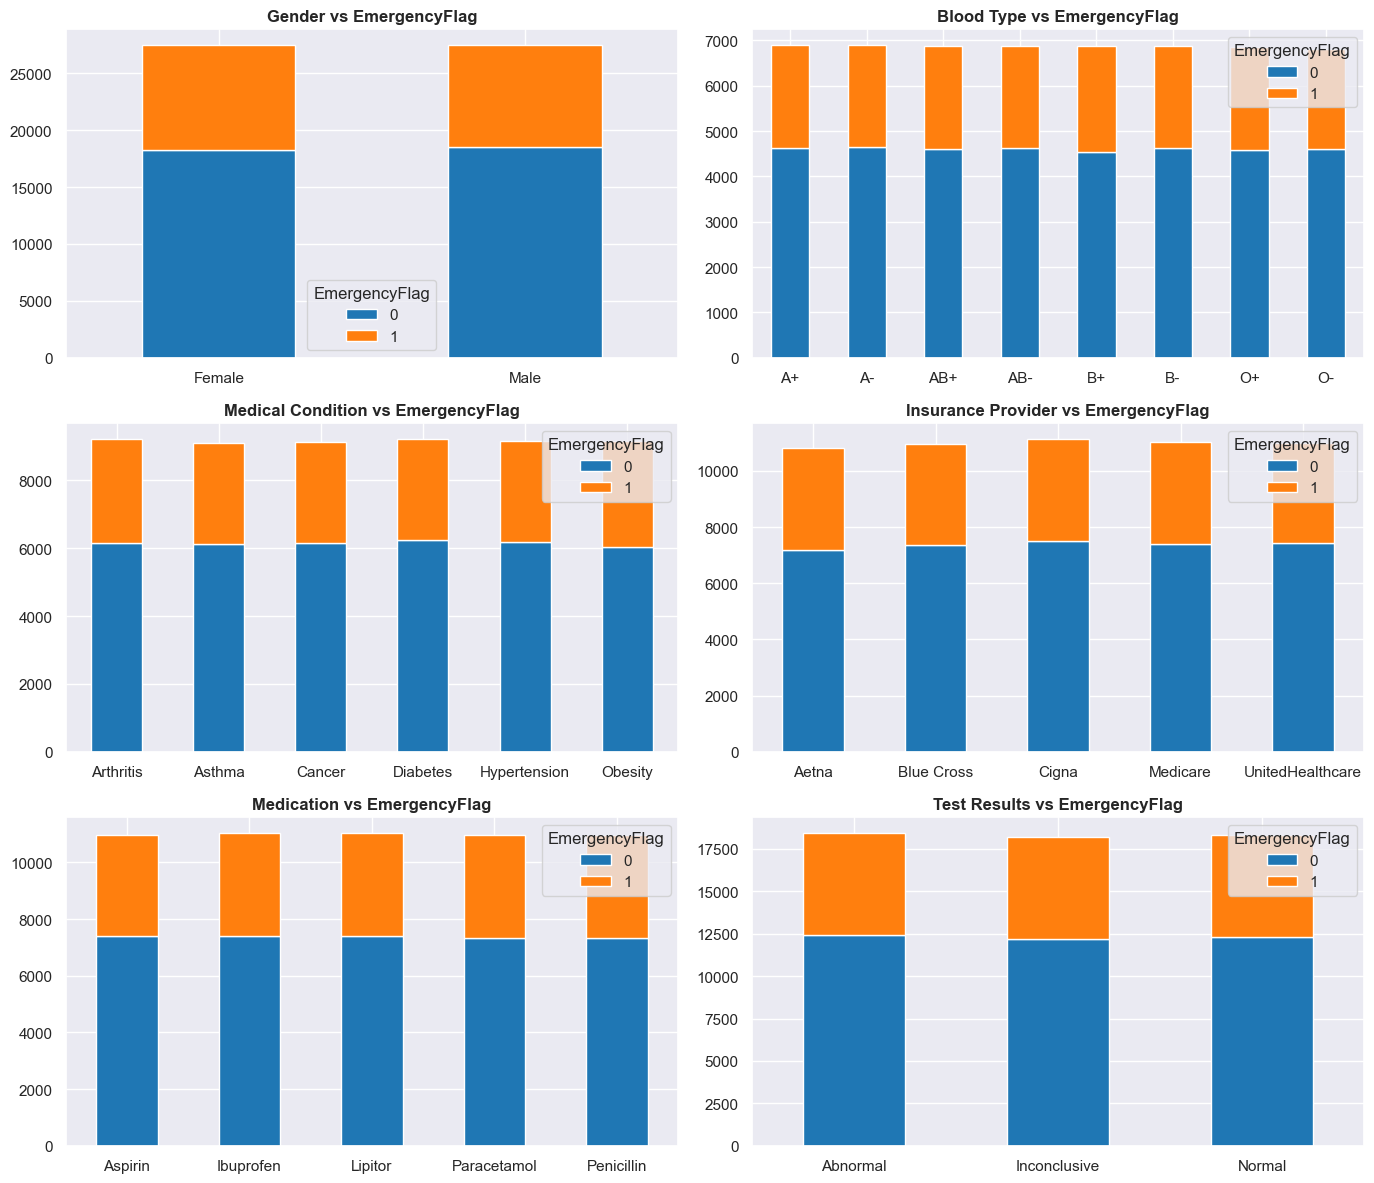

In [24]:
categorical_features = [
    'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Medication', 'Test Results'
]

target = 'EmergencyFlag'   # adjust if your actual column has a leading space

# Create subplot grid
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
axs = axs.flatten()  # makes indexing easy

for i, col in enumerate(categorical_features):
    
    # Cross-tabulation (use SAME dataframe consistently)
    ctab = pd.crosstab(data[col], data[target])
    
    # Plot on the correct subplot
    ctab.plot(
        kind='bar',
        stacked=True,
        ax=axs[i]
    )
    
    axs[i].set_title(f"{col} vs {target}", fontweight='bold', fontsize=12)
    axs[i].set_xlabel("")
    axs[i].tick_params(axis='x', rotation=360)

plt.tight_layout()
plt.show()

**Commnets** 

The bivariate analysis between the categorical variables and the target variable (EmergencyFlag) shows that emergency admissions occur across all categories with relatively similar proportions.
No single categorical variable dominates in predicting emergency admissions, implying that emergency visits may depend on the combined effect of multiple variables rather than any single category alone

### Feature Engineering

In [25]:
# Check Age ranges
print("Min age:", data["Age"].min())
print("Max age:", data["Age"].max())

Min age: 13
Max age: 89


In [26]:
#Create age ranges ---
age_bins = [12, 18, 30, 45, 60, 75, 90]  # covers 13–89 safely
age_labels = ["13–18", "19–30", "31–45", "46–60", "61–75", "76–89"]

data["age_range"] = pd.cut(
    data["Age"],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

# Frequency table (count + %) ---
age_freq = (
    data["age_range"]
    .value_counts(dropna=False)
    .reindex(age_labels)
    .fillna(0)
    .astype(int)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "age_range"})
)

age_freq["percentage"] = (
    age_freq["count"] / age_freq["count"].sum() * 100
).round(2)

print(age_freq)

  age_range  count  percentage
0     13–18    886        1.61
1     19–30   9519       17.32
2     31–45  12116       22.04
3     46–60  12273       22.33
4     61–75  12098       22.01
5     76–89   8074       14.69


**Comments**

The engineered age range variable shows that the dataset is largely composed of middle-aged and older adults. 
The largest proportions of patients fall within the 46–60 (22.33%), 31–45 (22.04%), and 61–75 (22.01%) age groups, indicating that individuals between 31 and 75 years represent the majority of the sample. 
The 19–30 age group accounts for 17.32%, while the 76–89 group represents 14.69% of the population.


<Figure size 1000x600 with 0 Axes>

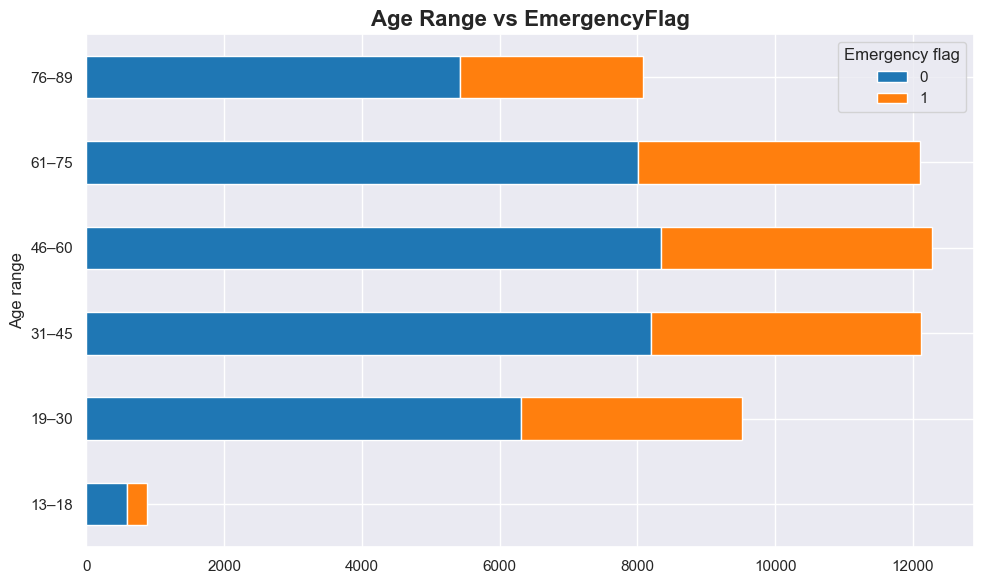

In [27]:
# Cross-tabulate Age ranges vs EmergencyFlag
age_range_ct = pd.crosstab(
    data["age_range"],
    data["EmergencyFlag"]
)
plt.figure(figsize=(10, 6))

age_range_ct.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Age Range vs EmergencyFlag", fontweight="bold", fontsize=16)
plt.xlabel("", fontsize=12)
plt.ylabel("Age range", fontsize=12)
plt.legend(title="Emergency flag")

plt.tight_layout()
plt.show()


**Comments**

The chart shows that non-emergency admissions (EmergencyFlag = 0) dominate across all age groups, indicating that most hospital admissions in the dataset are planned or non-emergency cases. However, the proportion of emergency admissions increases slightly among older age groups, particularly for patients aged 61–75 and 76–89.

The middle-age groups (31–45, 46–60, and 61–75) account for the largest number of both emergency and non-emergency admissions, which is consistent with their higher representation in the dataset. In contrast, the 13–18 age group has the lowest number of admissions overall and correspondingly very few emergency cases

In [28]:
# Convert the "Date of Admission" column to datetime format
# The errors="coerce" parameter will convert invalid dates to NaT (Not a Time) values
data["Date of Admission"] = pd.to_datetime(
    data["Date of Admission"],
    errors="coerce")

In [29]:
# Define the correct order of months for proper sorting
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

# Create a new categorical column 'admission_month' from the admission date
# - Extract month names from the Date of Admission column
# - Convert to categorical data type with proper month ordering
# - This enables correct chronological sorting of months in analyses
data["admission_month"] = pd.Categorical(
    data["Date of Admission"].dt.month_name(),
    categories=month_order,
    ordered=True
)

In [30]:
# Group data by admission month and emergency flag, then count occurrences
monthly_counts = (
    data
    .groupby(["admission_month", "EmergencyFlag"])  # Group by month and emergency status
    .size()                                         # Count records in each group
    .reset_index(name="count")                      # Convert to DataFrame with count column
)

# Create a pivot table to reshape data for easier visualization
monthly_pivot = monthly_counts.pivot(
    index="admission_month",                        # Rows represent months
    columns="EmergencyFlag",                        # Columns represent emergency status
    values="count"                                  # Values are the counts
).fillna(0)                                         # Replace NaN with 0 for months with no cases

#### Time series plot of Monthly Admissions

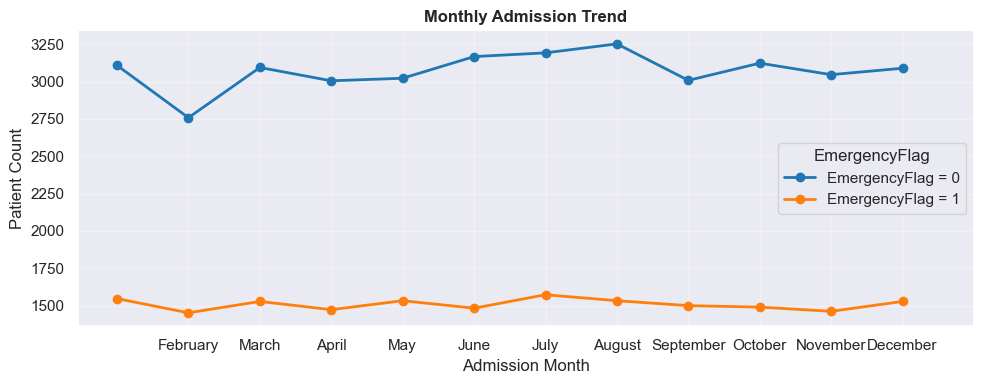

In [31]:
# Time series Plot of Monthly Admission
plt.figure(figsize=(10,4))   #  Create a figure with specified size (10x4 inches)

# Loop through each column in monthly_pivot (representing different EmergencyFlag values)
for col in monthly_pivot.columns:
    plt.plot(
        monthly_pivot.index,        # X-axis: month indices
        monthly_pivot[col],         # Y-axis: patient counts for this EmergencyFlag
        marker="o",                 # Add circular markers at each data point
        linewidth=2,                # Set line thickness
        label=f"EmergencyFlag = {col}"  # Create label for legend
    )

# Add chart title with bold formatting
plt.title("Monthly Admission Trend", fontweight="bold")
# Label the axes
plt.xlabel("Admission Month")
plt.ylabel("Patient Count")
# Set x-axis ticks to show months 1-12
plt.xticks(range(1,13))
# Add legend with title
plt.legend(title="EmergencyFlag")
# Add light grid lines for better readability
plt.grid(alpha=0.3)

# Adjust layout to prevent clipping of labels
plt.tight_layout()
# Display the plot
plt.show()

**Comments**

Non-emergency admissions remain relatively stable throughout the year, fluctuating slightly between approximately 2,750 and 3,250 patients per month, with a noticeable peak around August and a slight dip in February. Emergency admissions also show a fairly steady pattern, generally ranging between 1,450 and 1,600 cases per month.

Trends suggest minimal seasonal variation in hospital admissions, as both emergency and non-emergency cases remain relatively consistent across months.

### Remove irrelevant features

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                54966 non-null  object        
 1   Age                 54966 non-null  int64         
 2   Gender              54966 non-null  object        
 3   Blood Type          54966 non-null  object        
 4   Medical Condition   54966 non-null  object        
 5   Date of Admission   54966 non-null  datetime64[ns]
 6   Doctor              54966 non-null  object        
 7   Hospital            54966 non-null  object        
 8   Insurance Provider  54966 non-null  object        
 9   Billing Amount      54966 non-null  float64       
 10  Room Number         54966 non-null  int64         
 11  Admission Type      54966 non-null  object        
 12  Discharge Date      54966 non-null  object        
 13  Medication          54966 non-null  object        


In [36]:
data.drop(["Name", "Date of Admission", "Doctor", "Hospital", "Room Number", "Discharge Date"], axis=1, inplace=True)

In [37]:
# Check variables left in the dataset after dropping irrelevant ones
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 54966 non-null  int64   
 1   Gender              54966 non-null  object  
 2   Blood Type          54966 non-null  object  
 3   Medical Condition   54966 non-null  object  
 4   Insurance Provider  54966 non-null  object  
 5   Billing Amount      54966 non-null  float64 
 6   Admission Type      54966 non-null  object  
 7   Medication          54966 non-null  object  
 8   Test Results        54966 non-null  object  
 9   EmergencyFlag       54966 non-null  int64   
 10  age_range           54966 non-null  category
 11  admission_month     54966 non-null  category
dtypes: category(2), float64(1), int64(2), object(7)
memory usage: 4.7+ MB


### Data Splitting
We’ll split the cleaned dataset into training and testing sets

In [39]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Define the target variable (what we want to predict - emergency flag)
y = data["EmergencyFlag"]

# Define the feature set by removing the target variable from the dataset
X = data.drop("EmergencyFlag", axis=1)

# Split data into training and testing sets
# - 80% for training, 20% for testing
# - random_state ensures reproducibility
# - stratify=y maintains the same class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
# Print the number of samples in the training set
print("Training set size:", len(X_train))
# Print the number of samples in the testing set
print("Testing set size:", len(X_test))

Training set size: 43972
Testing set size: 10994


In [41]:
# Extract numeric features from the dataset
# Create a list of column names that have numeric data types
# Exclude the target variable 'EmergencyFlag' from the list
numeric_features = list(data.select_dtypes(include=['number']).columns.drop('EmergencyFlag'))
numeric_features

['Age', 'Billing Amount']

In [42]:
binary_features = ["Gender"]  # label encoded - features with only two categories that will be converted to 0/1

In [43]:
# List of categorical features in the dataset that will need special processing
# These include patient blood types, medical conditions, medications, test results
# and the month of hospital admission - all non-numeric data that needs encoding
categorical_features = [
    "Blood Type",
    "Medical Condition",
    "Medication",
    "Test Results",
    "admission_month",
    "age_range"           
]

### Classification Pipelines

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Create a preprocessing pipeline that applies different transformations to different feature types
preprocessor = ColumnTransformer(
    transformers=[
        # Scale numeric features to have zero mean and unit variance
        ("num", StandardScaler(), numeric_features),

        # Encode binary gender features as 0/1 using OrdinalEncoder
        # with explicit category ordering (Female=0, Male=1)
        ("bin", OrdinalEncoder(categories=[["Female", "Male"]]), binary_features),

        # One-hot encode categorical features
        # drop="first" removes first category to avoid multicollinearity
        # handle_unknown="ignore" prevents errors with unseen categories
        # sparse_output=False returns a dense array instead of sparse matrix
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop"  # Drop any columns not specified in the transformers
)

#### Pipeline

In [47]:
# Import necessary libraries
from imblearn.pipeline import Pipeline as ImbPipeline  # Pipeline that supports imbalanced data handling
from imblearn.over_sampling import SMOTE  # Synthetic Minority Over-sampling Technique for handling imbalanced classes
from sklearn.linear_model import LogisticRegression  # Classification algorithm

# Create an imbalanced learning pipeline with three steps
pipe = ImbPipeline(steps=[
    ("preprocess", preprocessor),  # First step: Apply preprocessing transformations
    ("smote", SMOTE(random_state=42)),  # Second step: Generate synthetic samples for minority class
                                                       
    ("model", LogisticRegression(
        max_iter=5000,  # Increase maximum iterations to ensure convergence
        solver="saga",  # Use SAGA solver which handles L1 penalty and is faster for large datasets
        class_weight="balanced"  # Adjust weights inversely proportional to class frequencies
    ))
])

#### Fit and Predict

In [48]:
# Train the pipeline on the training data
pipe.fit(X_train, y_train)
# Use the trained pipeline to make predictions on the test data
y_pred = pipe.predict(X_test)

print("pipeline trained")

pipeline trained


### Evaluate on test

In [49]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [50]:
# Evaluate performance
print("Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Non-Emergency', 'Emergency']))

Logistic Regression Classification Report:

               precision    recall  f1-score   support

Non-Emergency       0.67      0.58      0.62      7373
    Emergency       0.33      0.43      0.38      3621

     accuracy                           0.53     10994
    macro avg       0.50      0.51      0.50     10994
 weighted avg       0.56      0.53      0.54     10994



**Comment**
  
The logistic regression model shows moderate but limited predictive performance in distinguishing between emergency and non-emergency admissions.

Performance for Emergency admissions is weaker. The precision of 0.33 suggests that only about 33% of cases predicted as emergency are truly emergency cases, indicating a relatively high number of false positives. 

The recall of 0.43 shows that the model correctly identifies 43% of the actual emergency admissions, meaning more than half of emergency cases are still being missed. 

The F1-score of 0.38 confirms that the model struggles to effectively capture this class.

#### Cross Validation

In [51]:
# Stratified K-Fold preserves class distribution in each fold
# - n_splits=5: Creates 5 train/test splits (folds)
# - shuffle=True: Shuffles data before splitting for randomization
# - random_state=42: Sets seed for reproducible results
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [52]:
# Cross-validate metrics

cv_accuracy = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='precision')
cv_recall = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='recall')
cv_f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')

In [53]:
print(f"5-Fold Cross-Validation Results:")
print(f"  Accuracy:  {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std()*2:.4f})")
print(f"  Precision: {cv_precision.mean():.4f} (+/- {cv_precision.std()*2:.4f})")
print(f"  Recall:    {cv_recall.mean():.4f} (+/- {cv_recall.std()*2:.4f})")
print(f"  F1 Score:  {cv_f1.mean():.4f} (+/- {cv_f1.std()*2:.4f})")


5-Fold Cross-Validation Results:
  Accuracy:  0.5197 (+/- 0.0090)
  Precision: 0.3275 (+/- 0.0086)
  Recall:    0.4355 (+/- 0.0401)
  F1 Score:  0.3737 (+/- 0.0193)


***Comments***

The 5-fold cross-validation results indicate that the model demonstrates consistent but relatively modest predictive performance. The average accuracy of 0.52 (±0.009) suggests the model correctly classifies slightly more than half of the cases, with minimal variation across folds, indicating stable performance.

For the emergency class, the precision of 0.33 (±0.009) shows that only about one-third of predicted emergency cases are correct, reflecting a notable number of false positives. The recall of 0.44 (±0.04) indicates that the model is able to identify approximately 44% of actual emergency cases, meaning that more than half of emergency admissions remain undetected.

The F1 score of 0.38 (±0.019) reflects the overall balance between precision and recall and confirms that the model currently has limited effectiveness in identifying emergency admissions. However, the small standard deviations across folds suggest that the model’s performance is stable and generalizable across different subsets of the data, even though overall predictive power remains moderate.

#### Training multiple classification models

In [54]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [55]:
# class_weights={0:1, 1:3}
class_weights='balanced'
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight=class_weights),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight=class_weights),
    'Support Vector Machine': SVC(random_state=42, kernel='rbf', class_weight=class_weights),
    'k-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5, class_weight=class_weights),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42, algorithm="SAMME"),
    'XGBoost': XGBClassifier(eval_metric='mlogloss')
    }

Training Logistic Regression...
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.52      0.59      7373
           1       0.34      0.50      0.40      3621

    accuracy                           0.51     10994
   macro avg       0.51      0.51      0.50     10994
weighted avg       0.57      0.51      0.53     10994



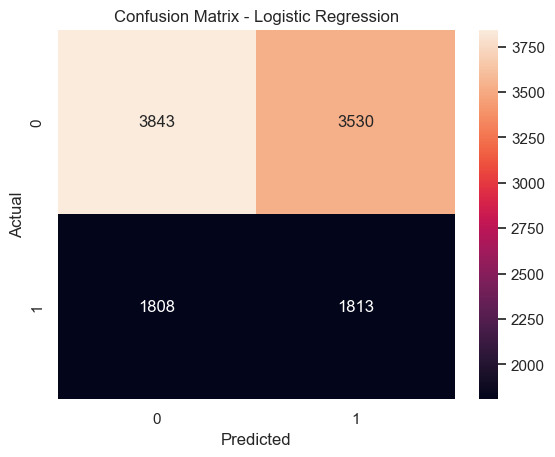

Training Random Forest...
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.95      0.80      7373
           1       0.60      0.16      0.26      3621

    accuracy                           0.69     10994
   macro avg       0.65      0.55      0.53     10994
weighted avg       0.66      0.69      0.62     10994



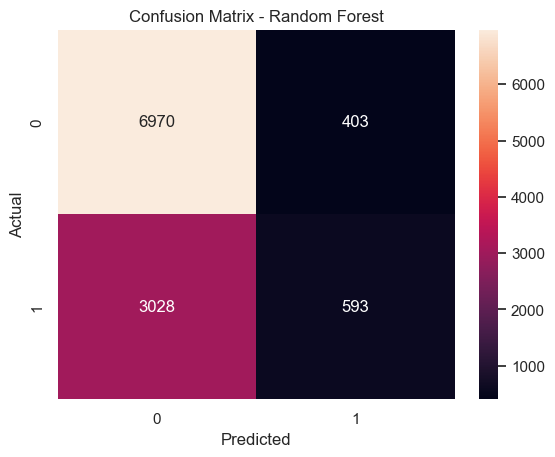

Training Support Vector Machine...
Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.53      0.60      7373
           1       0.35      0.52      0.42      3621

    accuracy                           0.53     10994
   macro avg       0.52      0.53      0.51     10994
weighted avg       0.58      0.53      0.54     10994



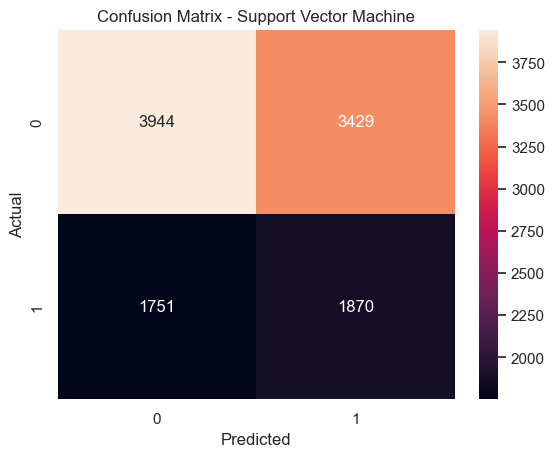

Training k-Nearest Neighbors...
k-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.79      0.73      7373
           1       0.38      0.25      0.30      3621

    accuracy                           0.62     10994
   macro avg       0.53      0.52      0.52     10994
weighted avg       0.58      0.62      0.59     10994



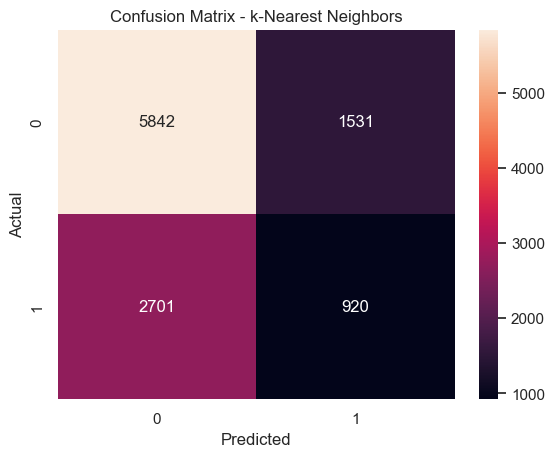

Training Decision Tree...
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.08      0.15      7373
           1       0.33      0.91      0.48      3621

    accuracy                           0.35     10994
   macro avg       0.49      0.50      0.31     10994
weighted avg       0.54      0.35      0.26     10994



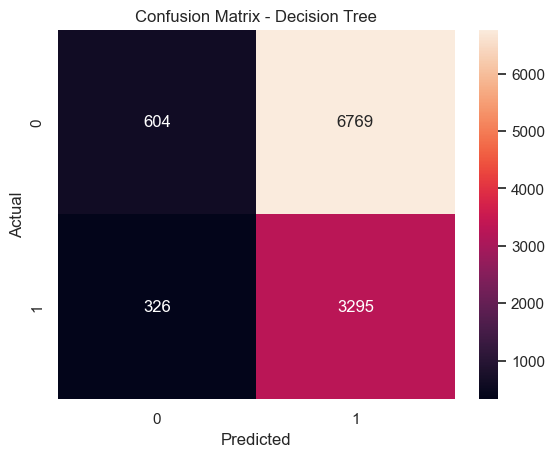

Training Gradient Boosting...
Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80      7373
           1       0.11      0.00      0.00      3621

    accuracy                           0.67     10994
   macro avg       0.39      0.50      0.40     10994
weighted avg       0.49      0.67      0.54     10994



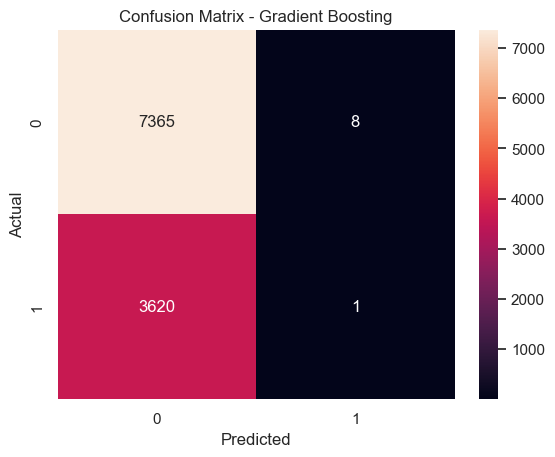

Training AdaBoost...
AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80      7373
           1       0.00      0.00      0.00      3621

    accuracy                           0.67     10994
   macro avg       0.34      0.50      0.40     10994
weighted avg       0.45      0.67      0.54     10994



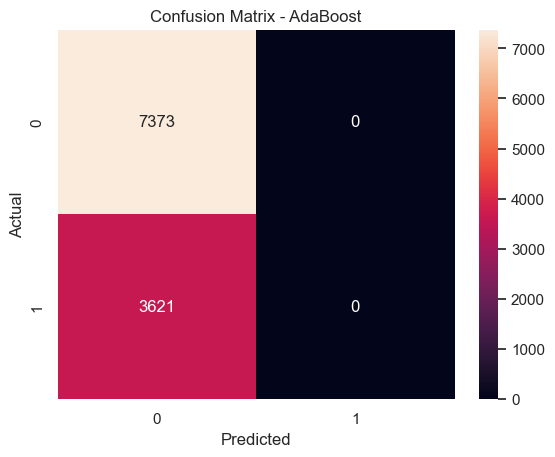

Training XGBoost...
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.96      0.79      7373
           1       0.42      0.06      0.10      3621

    accuracy                           0.66     10994
   macro avg       0.55      0.51      0.45     10994
weighted avg       0.59      0.66      0.57     10994



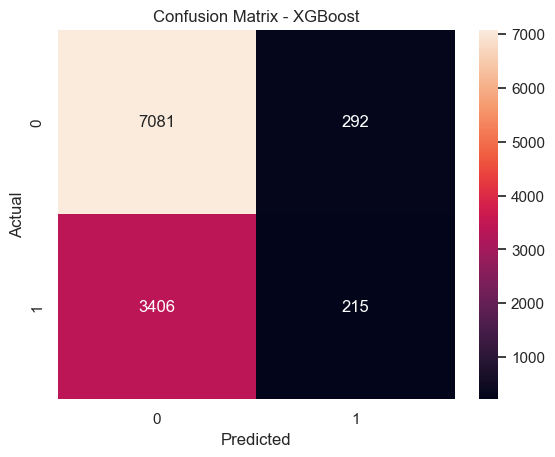

                 Model  CV F1 Mean  CV F1 Std  Test Accuracy  Test_Recall  Test F1
         Decision Tree      0.3124     0.1553         0.3546       0.9100   0.4815
Support Vector Machine      0.4075     0.0034         0.5288       0.5164   0.4193
   Logistic Regression      0.3946     0.0084         0.5145       0.5007   0.4045
   k-Nearest Neighbors      0.2830     0.0053         0.6151       0.2541   0.3030
         Random Forest      0.2261     0.0028         0.6879       0.1638   0.2569
               XGBoost      0.1143     0.0050         0.6636       0.0594   0.1042
     Gradient Boosting      0.0029     0.0019         0.6700       0.0003   0.0006
              AdaBoost      0.0000     0.0000         0.6706       0.0000   0.0000


In [56]:
results = {}
trained_pipelines = {}
summary_rows = []

for model_name, model in models.items():
    
    pipeline = ImbPipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    print(f"Training {model_name}...")
    
    # Cross-validation
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1")
    
    # Train pipeline on full training set
    pipeline.fit(X_train, y_train)
    
    # Save trained pipeline
    trained_pipelines[model_name] = pipeline
    
    # Predictions on test set
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_pred, zero_division=0)
    report = classification_report(y_test, y_pred, zero_division=0)
    matrix = confusion_matrix(y_test, y_pred)
    
    # Store detailed results
    results[model_name] = {
        "cv_f1_mean": cv_scores.mean(),
        "cv_f1_std": cv_scores.std(),
        "test_accuracy": accuracy,
        "test_recall": recall,
        "test_f1": test_f1,
        "classification_report": report,
        "confusion_matrix": matrix
    }
    
    # Store summary row
    summary_rows.append({
        "Model": model_name,
        "CV F1 Mean": round(cv_scores.mean(), 4),
        "CV F1 Std": round(cv_scores.std(), 4),
        "Test Accuracy": round(accuracy, 4),
        "Test_Recall": round(recall, 4),
        "Test F1": round(test_f1, 4)
    })
    
    # Print classification report
    print(f"{model_name} Classification Report:\n{report}")
    
    # Plot confusion matrix
    sns.heatmap(matrix, annot=True, fmt="g")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Summary dataframe
results_df = (
    pd.DataFrame(summary_rows)
    .sort_values(by="Test F1", ascending=False)
    .reset_index(drop=True)
)

print(results_df.to_string(index=False))

***Comments*** - The Decision Tree model achieved the highest recall (91%) and FI (48%) for emergency admissions and , indicating strong sensitivity in identifying emergency cases. However, this came at the cost of lower precision and overall accuracy, suggesting the model tends to overpredict emergency cases.

### Hyperparameter Tuning for Best Model (decision Tree)

In [70]:
# Define hyperparameter search space for grid search
param_grid = {
    "model__max_depth": [3, 5, 7, 10, 15],           # Maximum depth of the decision tree (prevents overfitting)
    "model__min_samples_split": [5, 10, 20, 50],     # Minimum samples required to split an internal node
    "model__min_samples_leaf": [2, 5, 10, 20],       # Minimum samples required at a leaf node
    "model__criterion": ["gini", "entropy"],         # Function to measure the quality of a split (impurity metrics)
    "model__ccp_alpha": [0.0, 0.001, 0.005, 0.01]    # Cost-Complexity Pruning parameter (higher values = more pruning)
}

In [71]:
from sklearn.model_selection import GridSearchCV

# Create a pipeline that combines preprocessing and model training
# ImbPipeline is likely a custom pipeline for imbalanced datasets
pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),  # Apply preprocessing transformations
    ("model", DecisionTreeClassifier(
        random_state=42,           # Set seed for reproducibility
        class_weight="balanced"    # Handle class imbalance by adjusting weights
    ))
])

# Set up grid search cross-validation to find optimal hyperparameters
grid = GridSearchCV(
    pipeline,                      # Pipeline to optimize
    param_grid,                    # Dictionary of parameters to search
    scoring="f1",                  # Optimize for F1 score (balance precision and recall)
    cv=5,                          # 5-fold cross-validation
    n_jobs=1                       # Use 1 CPU core
)

# Train the model with grid search
grid.fit(X_train, y_train)

# Print the best parameters and corresponding F1 score
print("Best Params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best Params: {'model__ccp_alpha': 0.0, 'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 5}
Best CV F1: 0.4532178670647805


In [73]:
# Get the best decision tree model from the grid search
best_tree = grid.best_estimator_

# Use the best model to make predictions on the test data
y_pred = best_tree.predict(X_test)

# Print the classification report which shows precision, recall, f1-score, and support for each class
print(classification_report(y_test, y_pred, target_names=["Non-Emergency", "Emergency"]))

               precision    recall  f1-score   support

Non-Emergency       0.66      0.13      0.22      7373
    Emergency       0.33      0.86      0.47      3621

     accuracy                           0.37     10994
    macro avg       0.49      0.50      0.34     10994
 weighted avg       0.55      0.37      0.30     10994



#### ROC Curve and AUC Score
ROC-AUC to evaluate the model's ability to distinguish between classes.

In [75]:
from sklearn.metrics import roc_curve, roc_auc_score

In [76]:
# Compute probabilities for ROC curve analysis
# Extract probability estimates for the positive class (class 1)
# This will be used to plot the ROC curve and calculate AUC
y_probs = best_tree.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

In [77]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

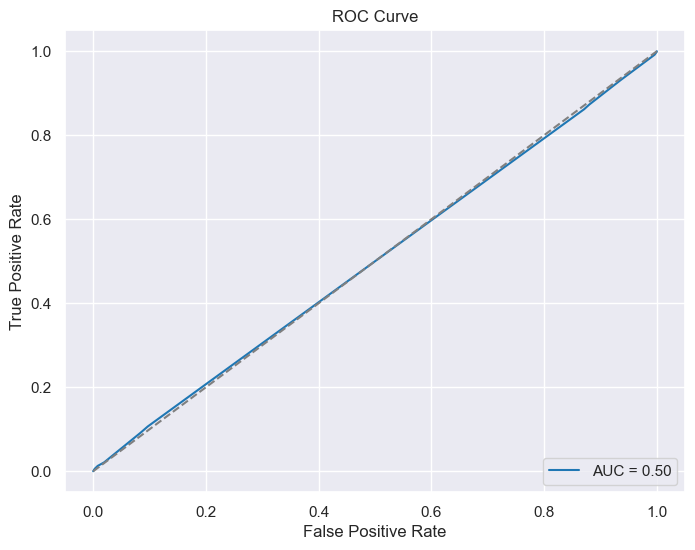

In [78]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

***Comment*** The best model achieved an Area Under the Curve (AUC) of 0.50, indicating that the model has no effective ability to distinguish between emergency and non-emergency admissions. This result suggests that the current model lacks sufficient predictive signal and highlights the need for additional or more informative features that better capture the factors driving emergency department (ED) admissions.

#### Generative AI Component

Gen A1 was used in problem research, support for code optimization, debugging, and aided structured interpretation of model results

#### Limitations & Assumptions

- Dataset : The Kaggle dataset does not include important clinical predictors such as triage scores, prior ED visits, or patient history.
This significantly impacted model performance and explains why the ROC-AUC remained low.
- An assumption is that all admissions are independent, whereas real-world healthcare data often involves repeated patient visits.


#### Conclusion

In conclusion, this project demonstrates how machine learning can be applied to predict emergency admissions, but also highlights that data quality is more important than model complexity.
With robust, real-world healthcare data, this approach could support better triage decisions, resource planning, and help reduce emergency department overcrowding.